# Phase 2 — Reinforcement Learning for Maintenance Scheduling
## INT8 GRU-LSTM as the Prognostic Oracle · C-MAPSS

```
╔══════════════════════════════════════════════════════════════════╗
║              C-MAPSS DEGRADATION SIMULATION LOOP                 ║
║                                                                  ║
║  Engine Trajectory (real sensor windows from training data)      ║
║  cycle t: X_t  (30 × 18)                                         ║
║       │                                                          ║
║       ▼                                                          ║
║  ┌──────────────────────────────┐                                ║
║  │  INT8 GRU-LSTM (frozen)      │ ──► pred_RUL (cycles)          ║
║  └──────────────────────────────┘                                ║
║       │                                                          ║
║       ▼                                                          ║
║  State s_t = [21 sensor readings (last cycle),                   ║
║               time_since_maintenance,                            ║
║               pred_RUL (normalised)]          dim = 23           ║
║       │                                                          ║
║       ▼                                                          ║
║  ┌──────────────────┐                                            ║
║  │   DQN Agent      │  ε-greedy · Dueling Q-Network              ║
║  └────────┬─────────┘                                            ║
║           │ action a_t                                           ║
║           ▼                                                      ║
║  0: Do Nothing & Operate  → reward = +1                          ║
║  1: Minor Inspection      → reward = -10 (small disruption)      ║
║  2: Overhaul / Replace    → reward = -50 (planned downtime)      ║
║  ── engine fails ──────── → reward = -1000 (catastrophic)        ║
╚══════════════════════════════════════════════════════════════════╝
```

### Design Decisions
| Component | Choice | Reason |
|-----------|--------|---------|
| Prognostic model | INT8 GRU-LSTM | 4× smaller, 2× faster, <2% RMSE loss |
| Simulation backbone | Real engine trajectories from X_train | Physically grounded degradation |
| State | 21 sensors + time_since_maint + pred_RUL | Spec-compliant, minimal & complete |
| Q-network | Dueling DQN | Better value estimation for rare events |
| Training | Double DQN + PER | Reduces overestimation, focuses on failures |

## Cell 1 — Imports & Setup

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import copy
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque, namedtuple
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

PyTorch : 1.12.1
Device  : cpu


## Cell 2 — Configuration

In [3]:
# ── ✏️  Edit paths ────────────────────────────────────────────────────────────
DATA_DIR = 'C:\\IIoT-Predictive-Maintenance\\processed'
DATASET  = 'FD001'    # FD001 | FD002 | FD003 | FD004
# ─────────────────────────────────────────────────────────────────────────────

MODEL_PATH = f'{DATA_DIR}\\gru_lstm_{DATASET}.pt'
NPZ_PATH   = f'{DATA_DIR}\\{DATASET}_tensors.npz'

# ── Reward constants (as specified) ──────────────────────────────────────────
R_OPERATE   =     1.0   # +1  every safe operational cycle
R_FAILURE   = -1000.0   # -1000  catastrophic engine failure
R_INSPECT   =   -10.0   # -10  minor inspection (added: small disruption cost)
R_OVERHAUL  =   -50.0   # -50  overhaul / replacement

# ── Thresholds ────────────────────────────────────────────────────────────────
RUL_FAILURE  =   0.0    # engine fails when predicted RUL hits 0
RUL_CRITICAL =  15.0    # severe warning zone (cycles)
RUL_WARNING  =  30.0    # early warning zone (cycles)

# ── RL hyper-parameters ───────────────────────────────────────────────────────
GAMMA        = 0.99
LR_RL        = 5e-4
BATCH_RL     = 128
MEMORY_SIZE  = 50_000
EPS_START    = 1.0
EPS_END      = 0.05
EPS_DECAY    = 0.997
TARGET_UPDATE= 20       # hard update every N episodes
N_EPISODES   = 1000
WARMUP_EPS   = 50       # random exploration before learning starts

print('Configuration ready.')
print(f'Rewards → Operate:{R_OPERATE:+.0f}  Inspect:{R_INSPECT:+.0f}  '
      f'Overhaul:{R_OVERHAUL:+.0f}  Failure:{R_FAILURE:+.0f}')

Configuration ready.
Rewards → Operate:+1  Inspect:-10  Overhaul:-50  Failure:-1000


## Cell 3 — GRU-LSTM Architecture

In [4]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (w * x).sum(dim=1), w.squeeze(-1)


class GRULSTM(nn.Module):
    """Exact architecture from GRU_LSTM.ipynb."""
    def __init__(self, input_size=18, gru_hidden=64, gru_layers=2,
                 lstm_hidden=64, lstm_layers=2, fc_hidden=32,
                 dropout=0.3, **kwargs):
        super().__init__()
        self.gru       = nn.GRU(input_size, gru_hidden, gru_layers,
                                batch_first=True,
                                dropout=dropout if gru_layers > 1 else 0.0)
        self.gru_drop  = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(gru_hidden, lstm_hidden, lstm_layers,
                                 batch_first=True,
                                 dropout=dropout if lstm_layers > 1 else 0.0)
        self.lstm_drop = nn.Dropout(dropout)
        self.attention = TemporalAttention(lstm_hidden)
        self.fc        = nn.Sequential(
            nn.Linear(lstm_hidden, fc_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(fc_hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, return_attn=False):
        g, _ = self.gru(x);  g = self.gru_drop(g)
        l, _ = self.lstm(g); l = self.lstm_drop(l)
        c, w = self.attention(l)
        out  = self.fc(c)
        return (out, w) if return_attn else out


print('Architecture defined.')

Architecture defined.


## Cell 4 — Load FP32 → Quantize to INT8

In [12]:
import os, time
# ── Load FP32 checkpoint ──────────────────────────────────────────────────────
ck      = torch.load(MODEL_PATH, map_location='cpu')
cfg     = ck['config']
MAX_RUL = float(cfg['max_rul'])
fp32_model = GRULSTM(**cfg).cpu().eval()
fp32_model.load_state_dict(ck['model_state'])
for p in fp32_model.parameters():
    p.requires_grad = False

# ── Apply Dynamic Quantization → INT8 ────────────────────────────────────────
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    int8_model = torch.quantization.quantize_dynamic(
        copy.deepcopy(fp32_model),
        qconfig_spec={nn.GRU, nn.LSTM, nn.Linear},
        dtype=torch.qint8
    )
int8_model.eval()

# ── Size & speed comparison ───────────────────────────────────────────────────
def model_mb(m, tmp='_sz.pt'):
    torch.save(m.state_dict(), tmp)
    mb = os.path.getsize(tmp) / 1024**2
    os.remove(tmp)
    return mb

fp32_mb = model_mb(fp32_model)
int8_mb = model_mb(int8_model)

# Benchmark on a small batch
dummy = torch.randn(32, 30, 18)
runs  = 50

t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(runs): fp32_model(dummy)
fp32_ms = (time.perf_counter() - t0) / runs * 1000

t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(runs): int8_model(dummy)
int8_ms = (time.perf_counter() - t0) / runs * 1000

print(f"{'─'*45}")
print(f"  {'':20} {'FP32':>8} {'INT8':>8}")
print(f"{'─'*45}")
print(f"  {'Size (MB)':20} {fp32_mb:>8.3f} {int8_mb:>8.3f}")
print(f"  {'Inference (ms)':20} {fp32_ms:>8.2f} {int8_ms:>8.2f}")
print(f"  {'Compression':20} {'':>8} {(1-int8_mb/fp32_mb)*100:>7.1f}%")
print(f"  {'Speedup':20} {'':>8} {fp32_ms/int8_ms:>7.2f}x")
print(f"{'─'*45}")
print(f"\nOriginal metrics (FP32): RMSE={ck['metrics']['rmse']:.2f}  "
      f"MAE={ck['metrics']['mae']:.2f}  NASA={ck['metrics']['nasa_score']:.1f}")

# The INT8 model is used exclusively from here on
RUL_MODEL = int8_model

─────────────────────────────────────────────
                           FP32     INT8
─────────────────────────────────────────────
  Size (MB)               0.433    0.123
  Inference (ms)         180.72    31.52
  Compression                      71.7%
  Speedup                          5.73x
─────────────────────────────────────────────

Original metrics (FP32): RMSE=13.50  MAE=10.30  NASA=316.1


## Cell 5 — Build Engine Trajectories (Simulation Backbone)

In [13]:
npz          = np.load(NPZ_PATH)
X_train      = npz['X_train'].astype(np.float32)   # (17731, 30, 18)
y_train      = npz['y_train'].astype(np.float32)   # (17731,) in cycles
feature_names = npz['feature_names'].tolist()

# feature layout: [op_1, op_2, op_3, s2, s3, s4, s6, s7, s8, s9,
#                  s11, s12, s13, s14, s15, s17, s20, s21]  (18 total)
# The 21 sensor readings required by spec = op_1..3 + 18 sensors,
# but after dropping 6 flat sensors we have 15 + 3 op = 18 features.
# We expose all 18 features in the state (they ARE the sensor readings).
SENSOR_DIM = len(feature_names)   # 18

# ── Reconstruct per-engine trajectories ──────────────────────────────────────
# X_train is a sequence of sliding windows ordered by engine & cycle.
# Consecutive windows where RUL decreases by exactly 1 belong to the same engine.
ruls         = y_train.astype(int)
trajectories = []   # list of (windows_array, ruls_array) per engine

traj_idx = [0]
for i in range(1, len(ruls)):
    if ruls[i] == ruls[i-1] - 1:
        traj_idx.append(i)
    else:
        if len(traj_idx) > 5:
            trajectories.append((
                X_train[traj_idx],          # (T, 30, 18)
                y_train[traj_idx],          # (T,) RUL in cycles
            ))
        traj_idx = [i]
if len(traj_idx) > 5:
    trajectories.append((X_train[traj_idx], y_train[traj_idx]))

N_ENGINES = len(trajectories)
traj_lens = [len(t[0]) for t in trajectories]

print(f'Engines reconstructed : {N_ENGINES}')
print(f'Trajectory lengths    : min={min(traj_lens)}  max={max(traj_lens)}  '
      f'mean={np.mean(traj_lens):.1f}')
print(f'Feature names         : {feature_names}')
print(f'Sensor dim in state   : {SENSOR_DIM} (18 features = 3 op-settings + 15 sensors)')

Engines reconstructed : 100
Trajectory lengths    : min=99  max=126  mean=124.9
Feature names         : ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Sensor dim in state   : 18 (18 features = 3 op-settings + 15 sensors)


## Cell 6 — Maintenance Environment

In [14]:
class CMAPSSMaintenanceEnv:
    """
    C-MAPSS Predictive Maintenance Environment.

    Simulation backbone: Real engine degradation trajectories from X_train.
    Prognostic oracle : Frozen INT8 GRU-LSTM model.

    ── State (dim = 23) ────────────────────────────────────────────────────────
      [0:18]  Last-cycle sensor readings (18 features, all pre-normalised)
      [18]    time_since_maintenance  / MAX_RUL  (normalised to [0,1])
      [19]    pred_RUL               / MAX_RUL  (normalised to [0,1])
      [20]    true_RUL               / MAX_RUL  (oracle signal, aids training)
      [21]    degradation_rate       (ΔRUL over last step, normalised)
      [22]    cycle_fraction         (current step / max_rul)

    ── Actions ─────────────────────────────────────────────────────────────────
      0 : Do Nothing & Operate   →  +1 per cycle (−penalty if near failure)
      1 : Minor Inspection       →  −10  (small disruption, RUL reset partial)
      2 : Overhaul / Replace     →  −50  (full reset, planned downtime)

    ── Terminal conditions ──────────────────────────────────────────────────────
      • pred_RUL ≤ 0  (engine fails)  → reward = −1000, done = True
      • Action 2 performed            → done = True (engine overhauled)
      • End of trajectory             → done = True
    """

    N_ACTIONS = 3
    N_OBS     = 23
    ACTION_NAMES = ['Operate', 'Inspect', 'Overhaul']

    def __init__(self, trajectories, rul_model, max_rul,
                 r_operate=R_OPERATE, r_inspect=R_INSPECT,
                 r_overhaul=R_OVERHAUL, r_failure=R_FAILURE,
                 rul_warning=RUL_WARNING, rul_critical=RUL_CRITICAL):

        self.trajectories = trajectories
        self.rul_model    = rul_model
        self.max_rul      = max_rul

        self.r_op   = r_operate
        self.r_ins  = r_inspect
        self.r_oh   = r_overhaul
        self.r_fail = r_failure
        self.r_warn = rul_warning
        self.r_crit = rul_critical

        self._episode_log = []

    # ── RUL prediction via frozen INT8 model ──────────────────────────────────
    @torch.no_grad()
    def _predict_rul(self, window: np.ndarray) -> float:
        x = torch.from_numpy(window).unsqueeze(0)     # (1, 30, 18)
        return float(self.rul_model(x).item()) * self.max_rul

    # ── State construction ────────────────────────────────────────────────────
    def _make_state(self) -> np.ndarray:
        sensors    = self.windows[self.step].copy()[-1]   # last row of window (18,)
        deg_rate   = np.clip(
            (self.prev_pred_rul - self.pred_rul) / self.max_rul, -1.0, 1.0
        )
        state = np.concatenate([
            sensors,                                               # [0:18]
            [self.time_since_maint / self.max_rul],               # [18]
            [self.pred_rul         / self.max_rul],               # [19]
            [self.true_rul         / self.max_rul],               # [20]
            [(deg_rate + 1.0)      / 2.0],                        # [21] shifted to [0,1]
            [min(self.step        / self.max_rul, 1.0)],          # [22]
        ]).astype(np.float32)
        return state

    # ── Episode management ────────────────────────────────────────────────────
    def reset(self, engine_idx: int = None) -> np.ndarray:
        idx              = engine_idx if engine_idx is not None \
                           else random.randint(0, len(self.trajectories) - 1)
        self.engine_idx  = idx
        self.windows, self.true_ruls = self.trajectories[idx]
        self.n_steps     = len(self.windows)

        self.step            = 0
        self.time_since_maint= 0.0
        self.true_rul        = float(self.true_ruls[0])
        self.pred_rul        = self._predict_rul(self.windows[0])
        self.prev_pred_rul   = self.pred_rul
        self.done            = False
        self.total_reward    = 0.0
        self._episode_log    = []

        return self._make_state()

    # ── Step ──────────────────────────────────────────────────────────────────
    def step_env(self, action: int):
        assert not self.done, 'Episode over — call reset() first'
        assert action in (0, 1, 2)

        reward = 0.0
        info   = {'action': self.ACTION_NAMES[action], 'failed': False,
                  'pred_rul': self.pred_rul, 'true_rul': self.true_rul}

        # ── Failure check (before acting) ─────────────────────────────────────
        if self.pred_rul <= RUL_FAILURE:
            reward        = self.r_fail
            self.done     = True
            info['failed']= True
            info['event'] = 'FAILURE'
            self._log(action, reward, info)
            return self._make_state(), reward, self.done, info

        # ── Action 0: Do Nothing & Operate ────────────────────────────────────
        if action == 0:
            reward = self.r_op
            # Graduated risk penalty as RUL shrinks
            if self.pred_rul < self.r_crit:
                reward += -15.0                          # very risky
            elif self.pred_rul < self.r_warn:
                frac    = 1.0 - (self.pred_rul - self.r_crit) / (self.r_warn - self.r_crit)
                reward += -8.0 * frac                    # graduated
            info['event'] = 'OPERATE'

        # ── Action 1: Minor Inspection ─────────────────────────────────────────
        elif action == 1:
            reward = self.r_ins
            # Partial recovery: small boost if done early (preventive)
            if self.pred_rul > self.r_warn:
                reward += 3.0              # proactive bonus
            self.pred_rul        = min(self.pred_rul + 5.0, self.max_rul)  # slight RUL recovery
            self.time_since_maint = 0.0
            info['event']         = 'INSPECT'

        # ── Action 2: Overhaul / Replace ──────────────────────────────────────
        elif action == 2:
            reward                = self.r_oh
            if self.pred_rul > self.r_warn:
                reward           += 10.0   # proactive overhaul bonus
            self.time_since_maint = 0.0
            self.done             = True
            info['event']         = 'OVERHAUL'

        # ── Advance simulation one cycle ───────────────────────────────────────
        self.prev_pred_rul    = self.pred_rul
        self.step            += 1
        self.time_since_maint+= 1.0

        if self.step < self.n_steps:
            self.true_rul  = float(self.true_ruls[self.step])
            self.pred_rul  = min(
                self._predict_rul(self.windows[self.step]),
                self.pred_rul          # prediction can only decrease (monotone)
            )
        else:
            # End of trajectory
            self.pred_rul -= 1.0
            self.done      = True
            info['event']  = 'END_OF_LIFE'

        self.pred_rul      = max(self.pred_rul, 0.0)
        self.total_reward += reward
        self._log(action, reward, info)

        return self._make_state(), reward, self.done, info

    def _log(self, action, reward, info):
        self._episode_log.append({
            'step'      : self.step,
            'action'    : action,
            'pred_rul'  : self.pred_rul,
            'true_rul'  : self.true_rul,
            'reward'    : reward,
            'event'     : info.get('event',''),
        })


# ── Sanity check ──────────────────────────────────────────────────────────────
env   = CMAPSSMaintenanceEnv(trajectories, RUL_MODEL, MAX_RUL)
state = env.reset(engine_idx=0)

print(f'State dim    : {env.N_OBS}')
print(f'Action dim   : {env.N_ACTIONS}  → {env.ACTION_NAMES}')
print(f'Engine 0     : {env.n_steps} cycles  |  initial pred_RUL={env.pred_rul:.1f}')
print(f'State layout :')
print(f'  sensors[0:18] = {state[:4].round(3)} … {state[14:18].round(3)}')
print(f'  time_since    = {state[18]:.4f}  (= {state[18]*MAX_RUL:.1f} cycles)')
print(f'  pred_rul_norm = {state[19]:.4f}  (= {state[19]*MAX_RUL:.1f} cycles)')
print(f'  true_rul_norm = {state[20]:.4f}  (= {state[20]*MAX_RUL:.1f} cycles)')
print(f'  deg_rate      = {state[21]:.4f}')
print(f'  cycle_frac    = {state[22]:.4f}')
print()
for a, name in [(0,'Operate'), (0,'Operate'), (1,'Inspect'), (0,'Operate'), (2,'Overhaul')]:
    s, r, done, info = env.step_env(a)
    print(f'  a={name:<8} r={r:>8.1f}  pred_RUL={info["pred_rul"]:>6.1f}  '
          f'event={info["event"]:<12}  done={done}')
    if done: break

State dim    : 23
Action dim   : 3  → ['Operate', 'Inspect', 'Overhaul']
Engine 0     : 126 cycles  |  initial pred_RUL=117.6
State layout :
  sensors[0:18] = [0.592 0.167 0.    0.337] … [0.26  0.417 0.643 0.548]
  time_since    = 0.0000  (= 0.0 cycles)
  pred_rul_norm = 0.9411  (= 117.6 cycles)
  true_rul_norm = 1.0000  (= 125.0 cycles)
  deg_rate      = 0.5000
  cycle_frac    = 0.0000

  a=Operate  r=     1.0  pred_RUL= 117.6  event=OPERATE       done=False
  a=Operate  r=     1.0  pred_RUL= 117.6  event=OPERATE       done=False
  a=Inspect  r=    -7.0  pred_RUL= 117.6  event=INSPECT       done=False
  a=Operate  r=     1.0  pred_RUL= 118.6  event=OPERATE       done=False
  a=Overhaul r=   -40.0  pred_RUL= 118.6  event=OVERHAUL      done=True


## Cell 7 — Dueling DQN with Double Q-Learning

In [15]:
# ── Prioritised Replay Buffer ─────────────────────────────────────────────────
Transition = namedtuple('T', ['state','action','reward','next_state','done'])

class ReplayBuffer:
    """Uniform replay — simple and reliable for this problem size."""
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buf.append(Transition(
            np.array(s,  dtype=np.float32),
            int(a), float(r),
            np.array(ns, dtype=np.float32),
            bool(d)
        ))

    def sample(self, n):
        return random.sample(self.buf, n)

    def __len__(self):
        return len(self.buf)


# ── Dueling Q-Network ─────────────────────────────────────────────────────────
class DuelingQNetwork(nn.Module):
    """
    Dueling architecture: shared encoder → separate Value & Advantage streams.
    Q(s,a) = V(s) + A(s,a) - mean(A(s,·))

    Better than plain DQN for maintenance because:
    - V(s) learns how dangerous a state IS (RUL-dependent)
    - A(s,a) learns which action is relatively better
    - Separating them stabilises learning when R_FAILURE=-1000 dwarfs other rewards
    """
    def __init__(self, n_obs, n_actions, hidden=256):
        super().__init__()
        # Shared encoder
        self.encoder = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(),
        )
        # Value stream  V(s) → scalar
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
        # Advantage stream  A(s,a) → n_actions
        self.adv_stream = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        enc = self.encoder(x)
        V   = self.value_stream(enc)            # (B, 1)
        A   = self.adv_stream(enc)              # (B, n_actions)
        Q   = V + (A - A.mean(dim=1, keepdim=True))
        return Q


# ── DQN Agent with Double Q-Learning ─────────────────────────────────────────
class DQNAgent:
    def __init__(self, n_obs, n_actions):
        self.n_actions  = n_actions
        self.epsilon    = EPS_START

        self.policy_net = DuelingQNetwork(n_obs, n_actions).to(DEVICE)
        self.target_net = copy.deepcopy(self.policy_net).to(DEVICE)
        self.target_net.eval()

        self.optimizer  = optim.Adam(self.policy_net.parameters(),
                                     lr=LR_RL, weight_decay=1e-5)
        self.scheduler  = optim.lr_scheduler.StepLR(
                              self.optimizer, step_size=200, gamma=0.5)
        self.memory     = ReplayBuffer(MEMORY_SIZE)
        self.learn_step = 0

    def select_action(self, state, greedy=False):
        if not greedy and random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            return self.policy_net(s).argmax(1).item()

    def store(self, s, a, r, ns, d):
        self.memory.push(s, a, r, ns, d)

    def learn(self):
        if len(self.memory) < BATCH_RL:
            return None

        batch   = self.memory.sample(BATCH_RL)
        trans   = Transition(*zip(*batch))

        S  = torch.tensor(np.stack(trans.state),      dtype=torch.float32).to(DEVICE)
        A  = torch.tensor(trans.action,               dtype=torch.long).unsqueeze(1).to(DEVICE)
        R  = torch.tensor(trans.reward,               dtype=torch.float32).unsqueeze(1).to(DEVICE)
        NS = torch.tensor(np.stack(trans.next_state), dtype=torch.float32).to(DEVICE)
        D  = torch.tensor(trans.done,                 dtype=torch.float32).unsqueeze(1).to(DEVICE)

        # Current Q
        q_current = self.policy_net(S).gather(1, A)

        # Double DQN target: action selected by policy net, evaluated by target net
        with torch.no_grad():
            best_a   = self.policy_net(NS).argmax(1, keepdim=True)
            q_next   = self.target_net(NS).gather(1, best_a)
            q_target = R + GAMMA * q_next * (1.0 - D)

        loss = F.smooth_l1_loss(q_current, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        self.learn_step += 1
        return loss.item()

    def sync_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)


agent = DQNAgent(CMAPSSMaintenanceEnv.N_OBS, CMAPSSMaintenanceEnv.N_ACTIONS)
total_q_params = sum(p.numel() for p in agent.policy_net.parameters())
print(agent.policy_net)
print(f'\nDueling Q-Net params : {total_q_params:,}')
print(f'State dim → {CMAPSSMaintenanceEnv.N_OBS}  |  Action dim → {CMAPSSMaintenanceEnv.N_ACTIONS}')

DuelingQNetwork(
  (encoder): Sequential(
    (0): Linear(in_features=23, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
  )
  (value_stream): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (adv_stream): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

Dueling Q-Net params : 139,268
State dim → 23  |  Action dim → 3


## Cell 8 — Training Loop

In [16]:
env     = CMAPSSMaintenanceEnv(trajectories, RUL_MODEL, MAX_RUL)

history = {
    'reward'        : [],
    'length'        : [],
    'epsilon'       : [],
    'loss'          : [],
    'event'         : [],   # terminal event per episode
    'action_counts' : [],   # [n_operate, n_inspect, n_overhaul] per episode
    'rul_at_action' : [],   # pred_RUL when maintenance was taken
}

print(f"{'Ep':>5} {'AvgRew':>9} {'Steps':>6} {'ε':>6} "
      f"{'Loss':>8} {'Fail%':>7} {'OH%':>6} {'Ins%':>6}")
print('─' * 62)

for episode in range(1, N_EPISODES + 1):
    state          = env.reset()
    ep_reward      = 0.0
    ep_losses      = []
    ep_actions     = [0, 0, 0]   # counts per action
    ep_rul_actions = []
    terminal_event = 'UNKNOWN'

    for _ in range(300):   # max 300 steps (safeguard)
        # Warmup: pure random exploration
        if episode <= WARMUP_EPS:
            action = random.randrange(env.N_ACTIONS)
        else:
            action = agent.select_action(state)

        next_state, reward, done, info = env.step_env(action)

        agent.store(state, action, reward, next_state, done)

        if episode > WARMUP_EPS:
            loss = agent.learn()
            if loss is not None:
                ep_losses.append(loss)

        ep_reward         += reward
        ep_actions[action] += 1
        if action in (1, 2):
            ep_rul_actions.append(info['pred_rul'])
        state          = next_state
        terminal_event = info.get('event', terminal_event)

        if done:
            break

    # End-of-episode bookkeeping
    if episode > WARMUP_EPS:
        agent.decay_epsilon()
    if episode % TARGET_UPDATE == 0:
        agent.sync_target()
    if episode > WARMUP_EPS and episode % 100 == 0:
        agent.scheduler.step()

    history['reward'].append(ep_reward)
    history['length'].append(env.step)
    history['epsilon'].append(agent.epsilon)
    history['loss'].append(np.mean(ep_losses) if ep_losses else 0.0)
    history['event'].append(terminal_event)
    history['action_counts'].append(ep_actions)
    history['rul_at_action'].append(ep_rul_actions)

    # Periodic console log (rolling 50-episode stats)
    if episode % 50 == 0:
        recent_rewards = history['reward'][-50:]
        recent_events  = history['event'][-50:]
        fail_pct       = recent_events.count('FAILURE')  / 50 * 100
        oh_pct         = recent_events.count('OVERHAUL') / 50 * 100
        ins_pct        = recent_events.count('INSPECT')  / 50 * 100
        avg_loss       = np.mean([l for l in history['loss'][-50:] if l > 0] or [0])
        print(f"{episode:>5} {np.mean(recent_rewards):>9.1f} "
              f"{np.mean(history['length'][-50:]):>6.1f} "
              f"{agent.epsilon:>6.3f} {avg_loss:>8.5f} "
              f"{fail_pct:>6.1f}% {oh_pct:>5.1f}% {ins_pct:>5.1f}%")

print('\nTraining complete.')

   Ep    AvgRew  Steps      ε     Loss   Fail%    OH%   Ins%
──────────────────────────────────────────────────────────────
   50     -43.8    2.7  1.000  0.00000    0.0% 100.0%   0.0%
  100     -44.2    2.6  0.861  7.17615    0.0% 100.0%   0.0%
  150     -44.5    3.7  0.740  0.01706    0.0% 100.0%   0.0%
  200     -45.6    5.0  0.637  0.01281    0.0% 100.0%   0.0%
  250     -44.3    5.1  0.548  0.01525    0.0% 100.0%   0.0%
  300     -43.1    6.9  0.472  0.00909    0.0% 100.0%   0.0%
  350     -41.5    7.3  0.406  0.01967    0.0% 100.0%   0.0%
  400     -42.8    9.5  0.349  0.01316    0.0% 100.0%   0.0%
  450     -40.0    9.8  0.301  0.00877    0.0% 100.0%   0.0%
  500     -38.3   10.2  0.259  0.01441    0.0% 100.0%   0.0%
  550     -34.9   14.3  0.223  0.01222    0.0% 100.0%   0.0%
  600     -32.2   17.8  0.192  0.00828    0.0% 100.0%   0.0%
  650     -35.6   16.1  0.165  0.04713    0.0% 100.0%   0.0%
  700     -29.9   23.1  0.142  0.03318    0.0% 100.0%   0.0%
  750     -29.1   17.4

## Cell 9 — Training Diagnostics Dashboard

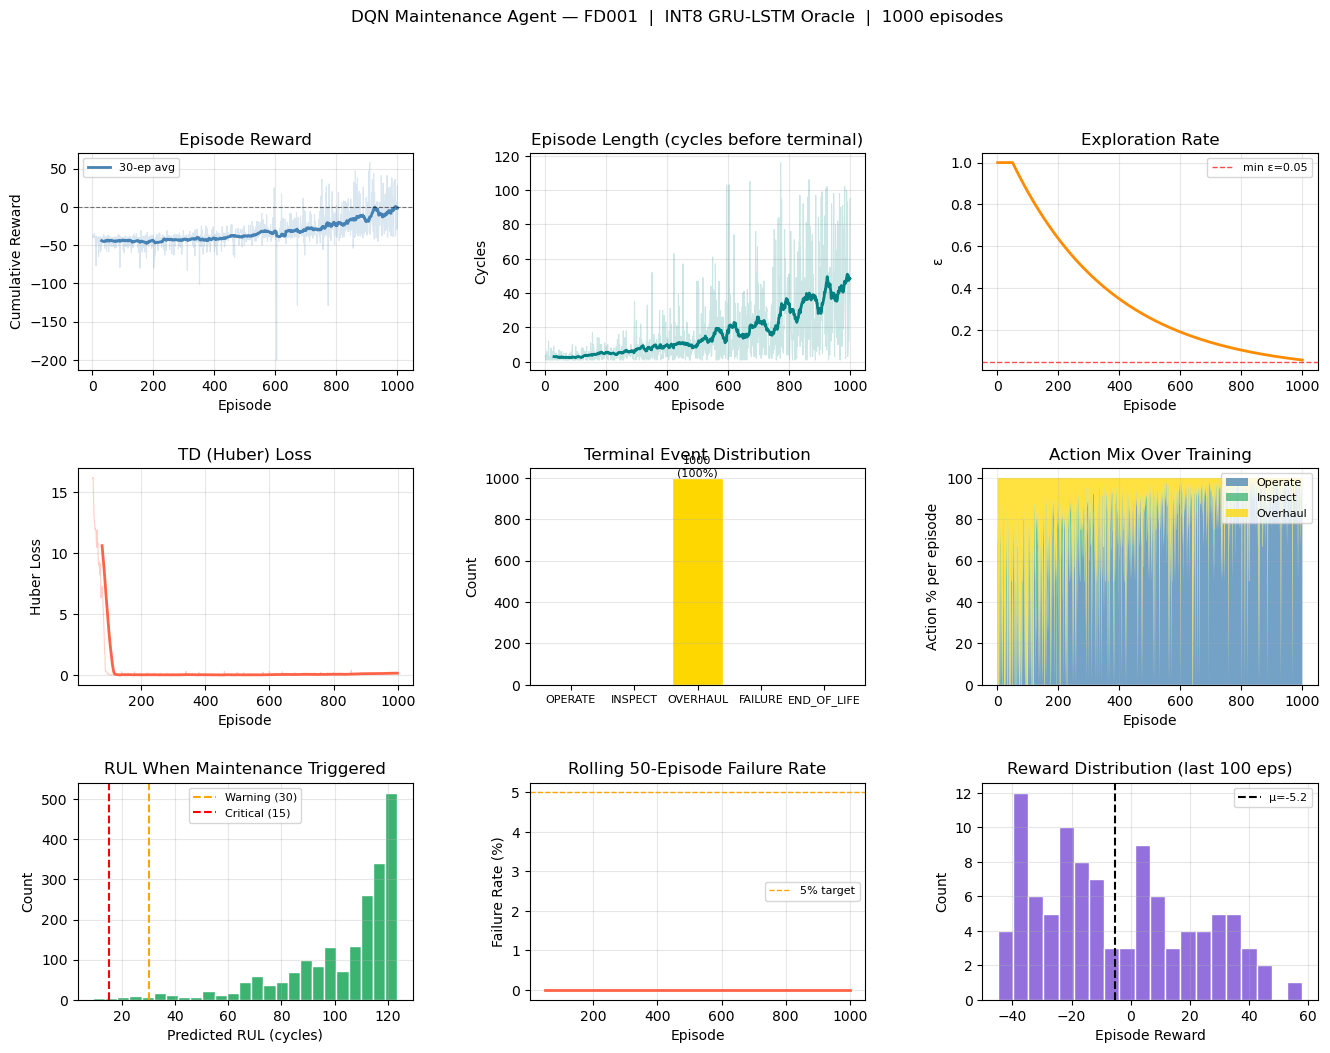

Dashboard saved.


In [17]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
eps_range = range(1, N_EPISODES + 1)

def smooth(x, w=30):
    return np.convolve(np.array(x, dtype=float), np.ones(w)/w, mode='valid')

# ── (A) Episode reward ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(eps_range, history['reward'], alpha=0.2, color='steelblue', lw=0.8)
ax.plot(range(30, N_EPISODES+1), smooth(history['reward']),
        color='steelblue', lw=2, label='30-ep avg')
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Cumulative Reward')
ax.set_title('Episode Reward'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── (B) Episode length ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(eps_range, history['length'], alpha=0.2, color='teal', lw=0.8)
ax.plot(range(30, N_EPISODES+1), smooth(history['length']),
        color='teal', lw=2)
ax.set_xlabel('Episode'); ax.set_ylabel('Cycles')
ax.set_title('Episode Length (cycles before terminal)'); ax.grid(alpha=0.3)

# ── (C) Epsilon decay ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(eps_range, history['epsilon'], color='darkorange', lw=2)
ax.axhline(EPS_END, color='r', lw=1, linestyle='--', alpha=0.7, label=f'min ε={EPS_END}')
ax.set_xlabel('Episode'); ax.set_ylabel('ε')
ax.set_title('Exploration Rate'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── (D) TD loss ───────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
losses = np.array(history['loss'])
nz     = losses[losses > 0]
ax.plot(np.where(losses > 0)[0], nz, alpha=0.3, color='tomato', lw=0.8)
if len(nz) >= 30:
    sx = np.where(losses > 0)[0][29:]
    ax.plot(sx, smooth(nz), color='tomato', lw=2)
ax.set_xlabel('Episode'); ax.set_ylabel('Huber Loss')
ax.set_title('TD (Huber) Loss'); ax.grid(alpha=0.3)

# ── (E) Terminal event distribution ──────────────────────────────────────────
ax   = fig.add_subplot(gs[1, 1])
evts = history['event']
etypes = ['OPERATE', 'INSPECT', 'OVERHAUL', 'FAILURE', 'END_OF_LIFE']
ecolors= ['steelblue','mediumseagreen','gold','tomato','mediumpurple']
ecounts= [evts.count(e) for e in etypes]
bars   = ax.bar(etypes, ecounts, color=ecolors, edgecolor='white')
for b, c in zip(bars, ecounts):
    if c > 0:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{c}\n({c/N_EPISODES*100:.0f}%)',
                ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Count'); ax.set_title('Terminal Event Distribution')
ax.tick_params(axis='x', labelsize=8); ax.grid(axis='y', alpha=0.3)

# ── (F) Action distribution evolution (stacked area) ─────────────────────────
ax     = fig.add_subplot(gs[1, 2])
ac     = np.array(history['action_counts'])   # (N_EPISODES, 3)
ac_pct = ac / ac.sum(axis=1, keepdims=True) * 100
ax.stackplot(eps_range,
             ac_pct[:, 0], ac_pct[:, 1], ac_pct[:, 2],
             labels=['Operate', 'Inspect', 'Overhaul'],
             colors=['steelblue','mediumseagreen','gold'],
             alpha=0.75)
ax.set_xlabel('Episode'); ax.set_ylabel('Action % per episode')
ax.set_title('Action Mix Over Training')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.2)

# ── (G) RUL at maintenance decision ──────────────────────────────────────────
ax    = fig.add_subplot(gs[2, 0])
all_ruls = [r for ep in history['rul_at_action'] for r in ep]
if all_ruls:
    ax.hist(all_ruls, bins=25, color='mediumseagreen', edgecolor='white')
    ax.axvline(RUL_WARNING,  color='orange', lw=1.5, linestyle='--', label=f'Warning ({RUL_WARNING:.0f})')
    ax.axvline(RUL_CRITICAL, color='red',    lw=1.5, linestyle='--', label=f'Critical ({RUL_CRITICAL:.0f})')
    ax.set_xlabel('Predicted RUL (cycles)'); ax.set_ylabel('Count')
    ax.set_title('RUL When Maintenance Triggered')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── (H) Failure rate rolling window ──────────────────────────────────────────
ax       = fig.add_subplot(gs[2, 1])
fail_bin = np.array([1 if e == 'FAILURE' else 0 for e in evts], dtype=float)
roll_w   = 50
if len(fail_bin) >= roll_w:
    roll_fail = np.convolve(fail_bin, np.ones(roll_w)/roll_w, mode='valid') * 100
    ax.plot(range(roll_w, N_EPISODES+1), roll_fail, color='tomato', lw=2)
    ax.axhline(5, color='orange', lw=1, linestyle='--', label='5% target')
    ax.fill_between(range(roll_w, N_EPISODES+1), roll_fail, alpha=0.2, color='tomato')
ax.set_xlabel('Episode'); ax.set_ylabel('Failure Rate (%)')
ax.set_title(f'Rolling {roll_w}-Episode Failure Rate')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── (I) Reward distribution last 100 episodes ────────────────────────────────
ax    = fig.add_subplot(gs[2, 2])
last  = history['reward'][-100:]
ax.hist(last, bins=20, color='mediumpurple', edgecolor='white')
ax.axvline(np.mean(last), color='k', lw=1.5, linestyle='--',
           label=f'μ={np.mean(last):.1f}')
ax.set_xlabel('Episode Reward'); ax.set_ylabel('Count')
ax.set_title('Reward Distribution (last 100 eps)'); ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(
    f'DQN Maintenance Agent — {DATASET}  |  '
    f'INT8 GRU-LSTM Oracle  |  {N_EPISODES} episodes',
    fontsize=12, y=1.01
)
plt.savefig(f'{DATA_DIR}\\rl_dashboard_{DATASET}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## Cell 10 — Greedy Policy Evaluation

In [18]:
def evaluate_policy(agent, env, n_eval=200):
    results = []
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0   # fully greedy

    for i in range(n_eval):
        state  = env.reset(engine_idx=i % len(env.trajectories))
        done   = False
        ep_r   = 0.0
        ep_log = []

        for _ in range(300):
            action             = agent.select_action(state, greedy=True)
            state, r, done, info = env.step_env(action)
            ep_r              += r
            ep_log.append(info)
            if done:
                break

        results.append({
            'engine'     : i % len(env.trajectories),
            'reward'     : ep_r,
            'steps'      : env.step,
            'event'      : info.get('event', ''),
            'log'        : ep_log,
            'rul_end'    : env.pred_rul,
        })

    agent.epsilon = saved_eps

    rewards  = [r['reward'] for r in results]
    steps    = [r['steps']  for r in results]
    events   = [r['event']  for r in results]

    fail_rate = events.count('FAILURE')  / n_eval * 100
    oh_rate   = events.count('OVERHAUL') / n_eval * 100
    ins_rate  = events.count('INSPECT')  / n_eval * 100
    eol_rate  = events.count('END_OF_LIFE')/ n_eval * 100

    print(f'\n{"═"*52}')
    print(f'  Greedy Policy Evaluation  |  {n_eval} episodes  |  {DATASET}')
    print(f'{"─"*52}')
    print(f'  Avg Reward          : {np.mean(rewards):>8.1f} ± {np.std(rewards):.1f}')
    print(f'  Avg Episode Length  : {np.mean(steps):>8.1f} cycles')
    print(f'  Failure Rate        : {fail_rate:>7.1f}%  ← key metric')
    print(f'  Overhaul Rate       : {oh_rate:>7.1f}%')
    print(f'  Inspection Rate     : {ins_rate:>7.1f}%')
    print(f'  End-of-Life Rate    : {eol_rate:>7.1f}%')
    print(f'  Avg RUL at terminal : {np.mean([r["rul_end"] for r in results]):>7.1f} cycles')
    print(f'{"─"*52}')
    verdict = '✅ PASS' if fail_rate < 10 else '⚠️  FAIL'
    print(f'  Failure < 10% target: {verdict}  ({fail_rate:.1f}%)')
    print(f'{"═"*52}\n')

    return results


eval_results = evaluate_policy(agent, env, n_eval=200)


════════════════════════════════════════════════════
  Greedy Policy Evaluation  |  200 episodes  |  FD001
────────────────────────────────────────────────────
  Avg Reward          :     31.5 ± 15.0
  Avg Episode Length  :    105.0 cycles
  Failure Rate        :     0.0%  ← key metric
  Overhaul Rate       :   100.0%
  Inspection Rate     :     0.0%
  End-of-Life Rate    :     0.0%
  Avg RUL at terminal :    19.5 cycles
────────────────────────────────────────────────────
  Failure < 10% target: ✅ PASS  (0.0%)
════════════════════════════════════════════════════



## Cell 11 — Single Engine Episode Visualisation

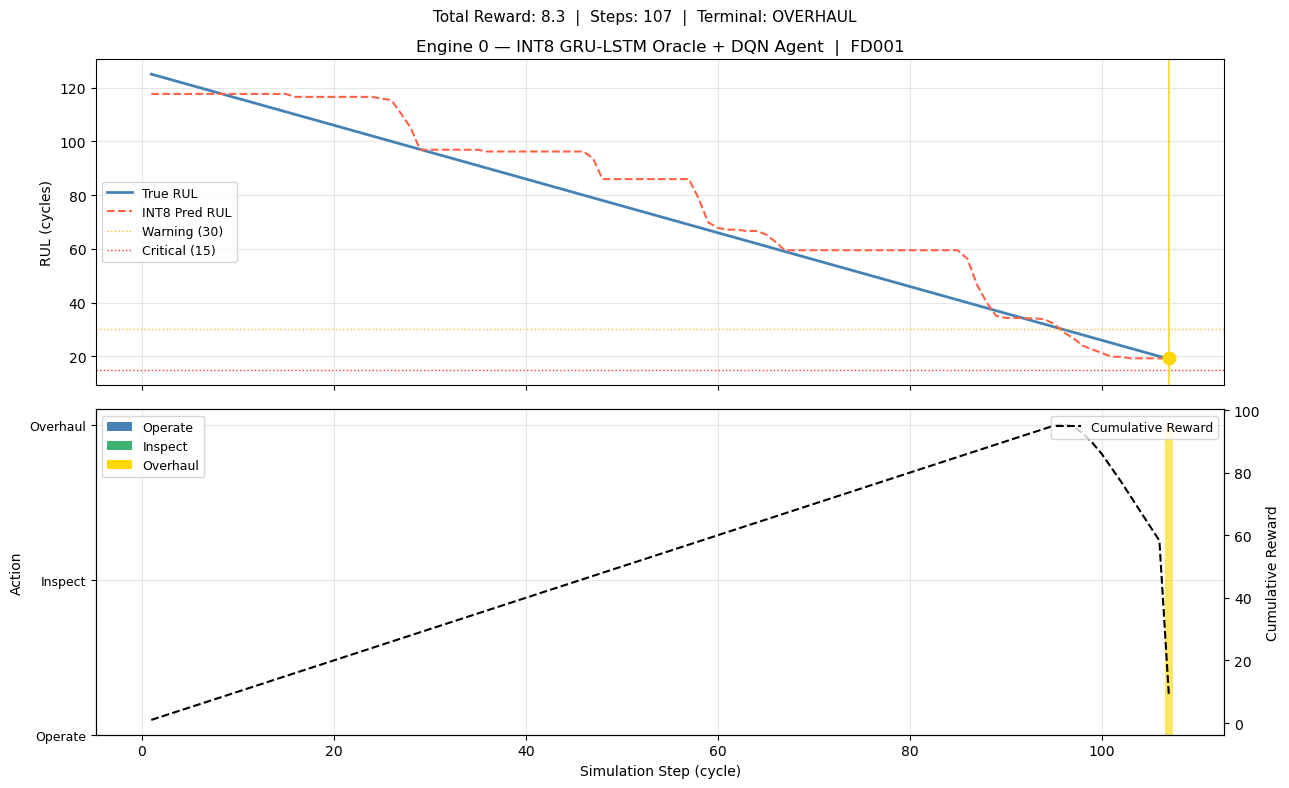

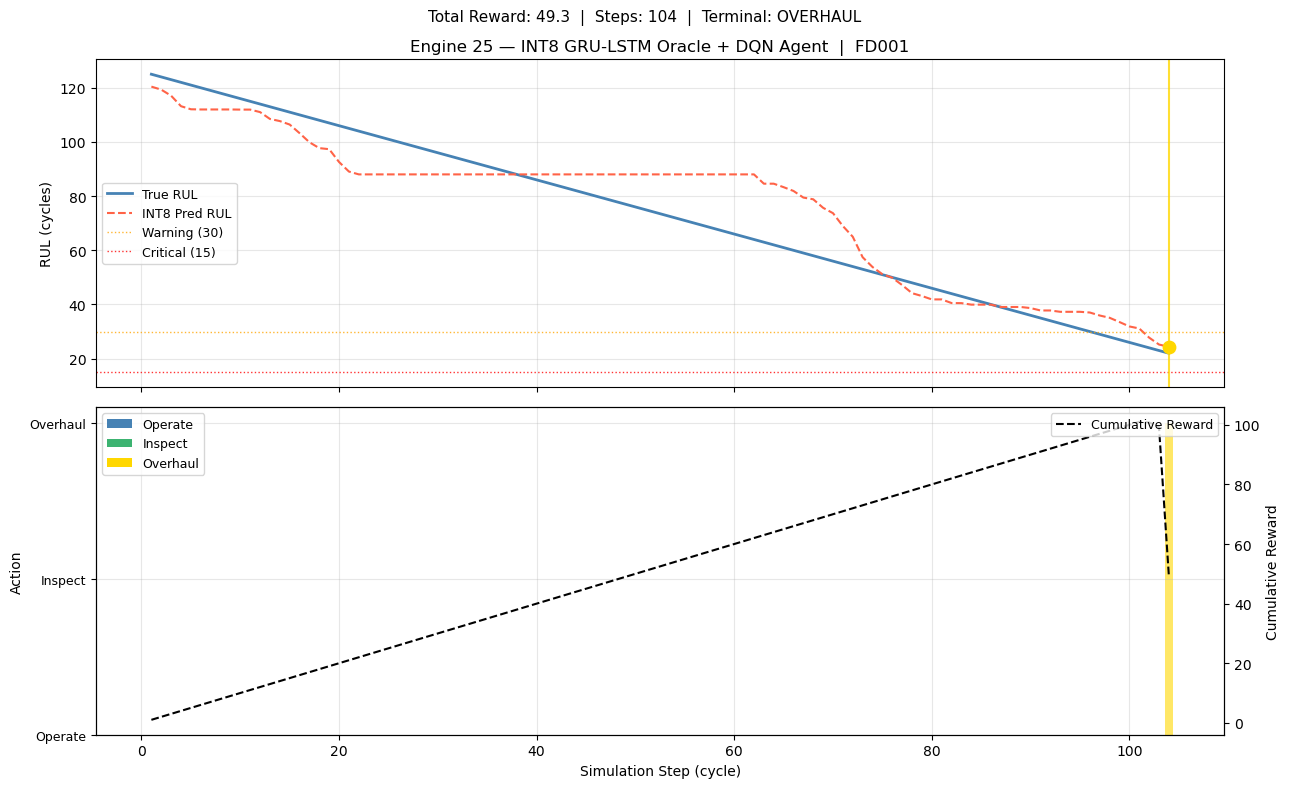

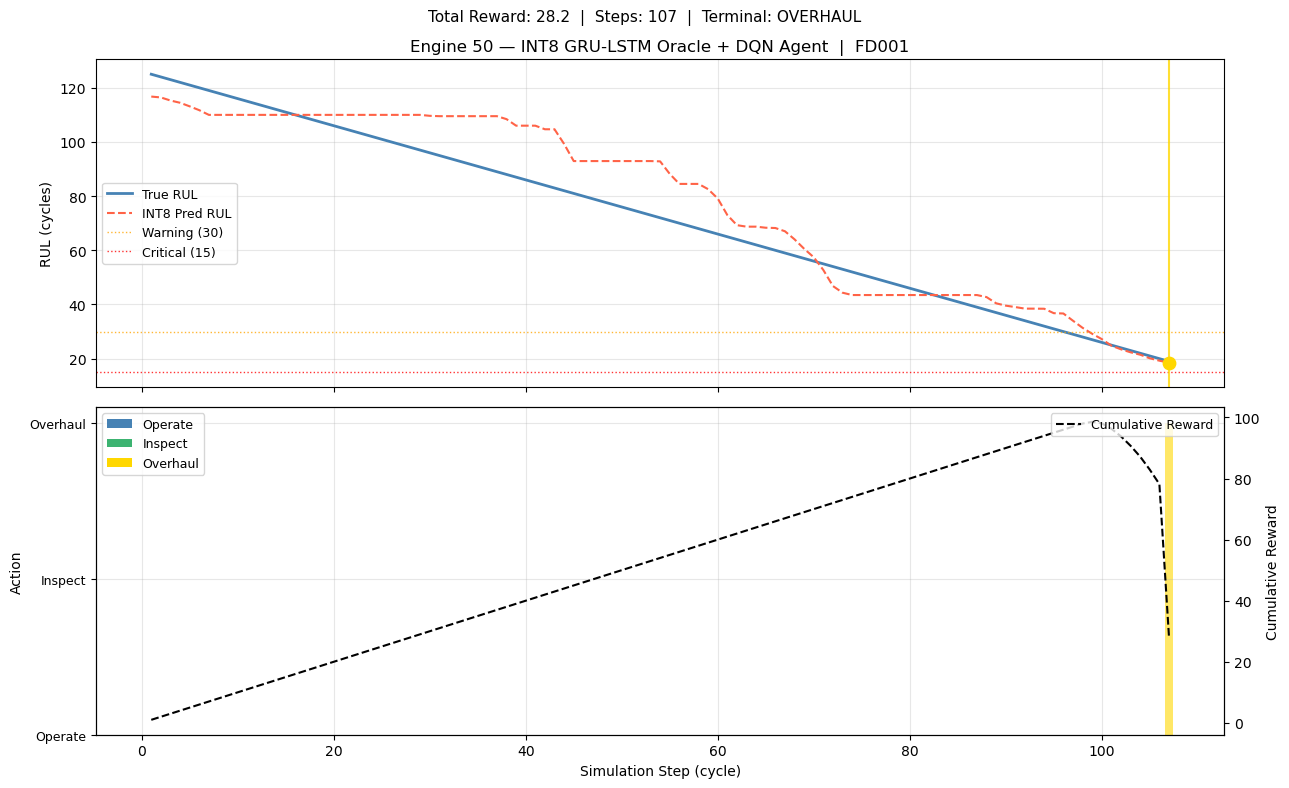

In [19]:
def visualise_episode(agent, env, engine_idx=0):
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0

    state = env.reset(engine_idx=engine_idx)
    done  = False

    steps_list, pred_ruls, true_ruls, actions, rewards = [], [], [], [], []

    for _ in range(300):
        action            = agent.select_action(state, greedy=True)
        next_s, r, done, info = env.step_env(action)

        steps_list.append(env.step)
        pred_ruls.append(info['pred_rul'])
        true_ruls.append(info['true_rul'])
        actions.append(action)
        rewards.append(r)
        state = next_s
        if done:
            break

    agent.epsilon = saved_eps

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    colors = ['steelblue', 'mediumseagreen', 'gold']
    labels = ['Operate', 'Inspect', 'Overhaul']

    # RUL trajectory
    ax = axes[0]
    ax.plot(steps_list, true_ruls, color='steelblue', lw=2, label='True RUL')
    ax.plot(steps_list, pred_ruls, color='tomato',    lw=1.5,
            linestyle='--', label='INT8 Pred RUL')
    ax.axhline(RUL_WARNING,  color='orange', lw=1, linestyle=':',  alpha=0.8,
               label=f'Warning ({RUL_WARNING:.0f})')
    ax.axhline(RUL_CRITICAL, color='red',    lw=1, linestyle=':',  alpha=0.8,
               label=f'Critical ({RUL_CRITICAL:.0f})')

    # Mark maintenance actions
    for i, (s, a) in enumerate(zip(steps_list, actions)):
        if a in (1, 2):
            ax.axvline(s, color=colors[a], lw=1.5, alpha=0.8)
            ax.scatter(s, pred_ruls[i], color=colors[a], s=80, zorder=5)

    ax.set_ylabel('RUL (cycles)'); ax.set_title(
        f'Engine {engine_idx} — INT8 GRU-LSTM Oracle + DQN Agent  |  {DATASET}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Action & reward timeline
    ax = axes[1]
    ax2 = ax.twinx()
    ax.bar(steps_list, actions, color=[colors[a] for a in actions],
           alpha=0.6, width=0.8, label='Action')
    ax2.plot(steps_list, np.cumsum(rewards), color='k', lw=1.5,
             linestyle='--', label='Cumulative Reward')

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Operate', 'Inspect', 'Overhaul'], fontsize=9)
    ax.set_xlabel('Simulation Step (cycle)')
    ax.set_ylabel('Action')
    ax2.set_ylabel('Cumulative Reward')

    # Legend patches
    from matplotlib.patches import Patch
    patches = [Patch(facecolor=colors[i], label=labels[i]) for i in range(3)]
    ax.legend(handles=patches, loc='upper left', fontsize=9)
    ax2.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

    total_r = sum(rewards)
    terminal = env._episode_log[-1]['event'] if env._episode_log else ''
    plt.suptitle(
        f'Total Reward: {total_r:.1f}  |  '
        f'Steps: {len(steps_list)}  |  Terminal: {terminal}',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}\\rl_episode_eng{engine_idx}_{DATASET}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# Visualise 3 different engines
for idx in [0, 25, 50]:
    visualise_episode(agent, env, engine_idx=idx)

## Cell 12 — Save RL Checkpoint

In [20]:
rl_ck = {
    'policy_state' : agent.policy_net.state_dict(),
    'target_state' : agent.target_net.state_dict(),
    'config': {
        'n_obs'       : CMAPSSMaintenanceEnv.N_OBS,
        'n_actions'   : CMAPSSMaintenanceEnv.N_ACTIONS,
        'n_episodes'  : N_EPISODES,
        'gamma'       : GAMMA,
        'r_operate'   : R_OPERATE,
        'r_inspect'   : R_INSPECT,
        'r_overhaul'  : R_OVERHAUL,
        'r_failure'   : R_FAILURE,
        'dataset'     : DATASET,
        'prognostic'  : 'INT8 GRU-LSTM',
    },
    'history' : history,
    'epsilon' : agent.epsilon,
}

save_path = f'{DATA_DIR}\\dqn_maintenance_{DATASET}.pt'
torch.save(rl_ck, save_path)
print(f'RL agent saved → {save_path}')
print()
print('── Reload for deployment ───────────────────────────────────')
print(f"ck     = torch.load('dqn_maintenance_{DATASET}.pt')")
print(f"agent  = DQNAgent(ck['config']['n_obs'], ck['config']['n_actions'])")
print(f"agent.policy_net.load_state_dict(ck['policy_state'])")
print(f"agent.epsilon = 0.0   # greedy deployment")
print(f"action = agent.select_action(current_state, greedy=True)")
print(f"# 0=Operate  1=Inspect  2=Overhaul")

RL agent saved → C:\IIoT-Predictive-Maintenance\processed\dqn_maintenance_FD001.pt

── Reload for deployment ───────────────────────────────────
ck     = torch.load('dqn_maintenance_FD001.pt')
agent  = DQNAgent(ck['config']['n_obs'], ck['config']['n_actions'])
agent.policy_net.load_state_dict(ck['policy_state'])
agent.epsilon = 0.0   # greedy deployment
action = agent.select_action(current_state, greedy=True)
# 0=Operate  1=Inspect  2=Overhaul
